|Machine Learning Lab 03 |                   |          
|:-----------------------------------:|:-----------------:|
| **World Development Indicators**           |                    |

|                 |                   | 
|-----------------|:-----------------:|
| **Name**        | Shubham Choudhary |        
| **Roll Number** | 212405015         |

# Setting up dataset

## 1. Importing the required libraries for EDA

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)

## 2. Loading the data into the data frame.

In [2]:
df = pd.read_csv('world-bank.csv')
df

,Country Name,Country Code,Region,IsCountry,Income group,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
0,Afghanistan,AFG,South Asia,1,Low income,2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,South Asia,1,Low income,2021,NaN,-2.529855,NaN,1.052000,...,4.643000,NaN,NaN,NaN,NaN,NaN,NaN,2.267802e+07,1.457870e+05,NaN
2,Afghanistan,AFG,South Asia,1,Low income,2020,1.500000,-2.705030,0.38689,1.052000,...,4.750000,6.522300e+05,1.852782,NaN,NaN,59.752281,NaN,2.267802e+07,1.457870e+05,NaN
3,Afghanistan,AFG,South Asia,1,Low income,2019,1.500000,-2.655531,NaN,1.053000,...,4.870000,6.522300e+05,1.852782,NaN,NaN,57.908252,NaN,2.258007e+07,1.346360e+05,NaN
4,Afghanistan,AFG,South Asia,1,Low income,2018,1.500000,-2.763864,0.34523,1.053000,...,5.002000,6.522300e+05,1.852782,NaN,NaN,56.248231,NaN,2.197636e+07,1.277940e+05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2655,World,WLD,NaN,0,NaN,2017,3.216216,NaN,1.11526,1.065901,...,2.459195,1.299797e+08,31.289988,NaN,NaN,58.302608,14.159733,7.696088e+09,9.838457e+08,1.295733e+13
2656,World,WLD,NaN,0,NaN,2016,3.239726,NaN,1.11054,1.067631,...,2.481092,1.299870e+08,31.340906,NaN,NaN,57.636017,13.868484,7.451633e+09,1.007991e+09,1.278231e+13
2657,World,WLD,NaN,0,NaN,2015,3.309211,NaN,1.10362,1.067427,...,2.477870,1.299772e+08,31.368377,1.277164e+08,1.907334e+06,56.970835,13.983647,7.131648e+09,1.045943e+09,1.257138e+13
2658,World,WLD,NaN,0,NaN,2014,3.322368,NaN,1.10298,1.069780,...,2.506561,1.299736e+08,31.403798,NaN,NaN,56.299967,13.978085,6.966385e+09,1.091283e+09,1.238212e+13


## 3. Checking the types of data

In [3]:
df.dtypes

Country Name              object
Country Code              object
Region                    object
IsCountry                  int64
Income group              object
Year                       int64
GenderEquality           float64
PoliticalStability       float64
GenderEducation          float64
BirthSex                 float64
Income                   float64
PlanePassengers          float64
PlaneDepartures          float64
Electricity              float64
PM2.5                    float64
CO2Emissions             float64
Unemployment             float64
Poverty                  float64
BattleDeaths             float64
CompulsoryEducation      float64
Literacy                 float64
Death                    float64
Alcohol                  float64
Diabetes                 float64
DeathsCD                 float64
DeathsNCD                float64
GDP                      float64
Internet                 float64
Population               float64
Rural                    float64
Urban     

In [4]:
df.columns

Index(['Country Name', 'Country Code', 'Region', 'IsCountry', 'Income group',
       'Year', 'GenderEquality', 'PoliticalStability', 'GenderEducation',
       'BirthSex', 'Income', 'PlanePassengers', 'PlaneDepartures',
       'Electricity', 'PM2.5', 'CO2Emissions', 'Unemployment', 'Poverty',
       'BattleDeaths', 'CompulsoryEducation', 'Literacy', 'Death', 'Alcohol',
       'Diabetes', 'DeathsCD', 'DeathsNCD', 'GDP', 'Internet', 'Population',
       'Rural', 'Urban', 'Suicide', 'Homicide', 'Military', 'LegalRights',
       'Birth', 'Fertility', 'LandArea', 'ForestArea', 'RuralArea',
       'UrbanArea', 'Density', 'TaxRevenue', 'Mobile', 'FixedTelephone',
       'GovernmentExpenditure'],
      dtype='object')

In [5]:
df.describe()

,IsCountry,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,Income,PlanePassengers,PlaneDepartures,Electricity,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
count,2660.000000,2660.000000,1041.000000,1845.000000,1454.000000,2385.000000,1.549000e+03,1.831000e+03,1.831000e+03,2110.000000,...,2324.000000,2.104000e+03,2096.000000,2.630000e+02,2.630000e+02,2104.000000,1429.000000,2.268000e+03,2.269000e+03,1.780000e+03
mean,0.796992,2017.500000,3.274738,-0.030259,1.101768,1.053751,2.674602e+12,1.406769e+08,1.321466e+06,84.015988,...,2.691507,5.203134e+06,31.793816,5.117519e+06,7.313158e+04,366.760802,16.549028,3.194685e+08,3.551202e+07,3.856625e+11
std,0.402314,2.872821,0.578462,0.998103,0.274458,0.023612,7.880351e+12,4.226116e+08,3.964975e+06,25.207334,...,1.310515,1.505450e+07,22.879478,1.482169e+07,2.345572e+05,1790.169570,6.687226,9.904078e+08,1.137194e+08,1.475196e+12
min,0.000000,2013.000000,1.500000,-3.005906,0.197120,1.009000,1.744913e+08,0.000000e+00,0.000000e+00,3.607868,...,0.772000,2.027000e+00,0.000000,3.495452e-02,0.000000e+00,0.136492,0.000079,3.400000e+03,0.000000e+00,6.371175e+07
25%,1.000000,2015.000000,3.000000,-0.631015,0.966385,1.039133,1.257729e+10,5.866140e+05,1.094236e+04,74.603631,...,1.670000,2.072000e+04,11.751692,1.929835e+04,3.349704e+02,35.411957,11.720265,2.550536e+06,7.600200e+04,2.085887e+09
50%,1.000000,2017.500000,3.277778,0.046548,1.156055,1.052000,8.162285e+10,4.908235e+06,5.648200e+04,99.300003,...,2.210500,1.968500e+05,30.351778,2.014560e+05,2.109344e+03,78.176763,15.500089,1.098950e+07,8.290970e+05,1.273025e+10
75%,1.000000,2020.000000,3.500000,0.840857,1.281682,1.063000,9.990276e+11,4.786999e+07,5.239430e+05,100.000000,...,3.470250,1.259200e+06,45.944741,1.251288e+06,1.544645e+04,194.473998,20.691075,7.933074e+07,6.691609e+06,1.194183e+11
max,1.000000,2022.000000,4.500000,1.965062,1.872170,1.282000,6.884001e+13,4.455690e+09,3.808293e+07,100.000000,...,7.344000,1.299870e+08,97.890679,1.277164e+08,1.907334e+06,20734.058442,93.879013,8.479624e+09,1.142279e+09,1.420213e+13


In [6]:
df.shape

(2660, 46)

## 4.Checking for duplicates

In [7]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 46)


##### There are no duplicates in data.

## 5. Checking for Null Values

In [8]:
df.isnull().sum()

Country Name                0
Country Code                0
Region                    540
IsCountry                   0
Income group              550
Year                        0
GenderEquality           1619
PoliticalStability        815
GenderEducation          1206
BirthSex                  275
Income                   1111
PlanePassengers           829
PlaneDepartures           829
Electricity               550
PM2.5                    1450
CO2Emissions              987
Unemployment              318
Poverty                  2284
BattleDeaths             2232
CompulsoryEducation       473
Literacy                 1922
Death                     300
Alcohol                  2190
Diabetes                 2400
DeathsCD                 2198
DeathsNCD                2198
GDP                       360
Internet                  500
Population                275
Rural                     293
Urban                     293
Suicide                  1043
Homicide                 1333
Military  

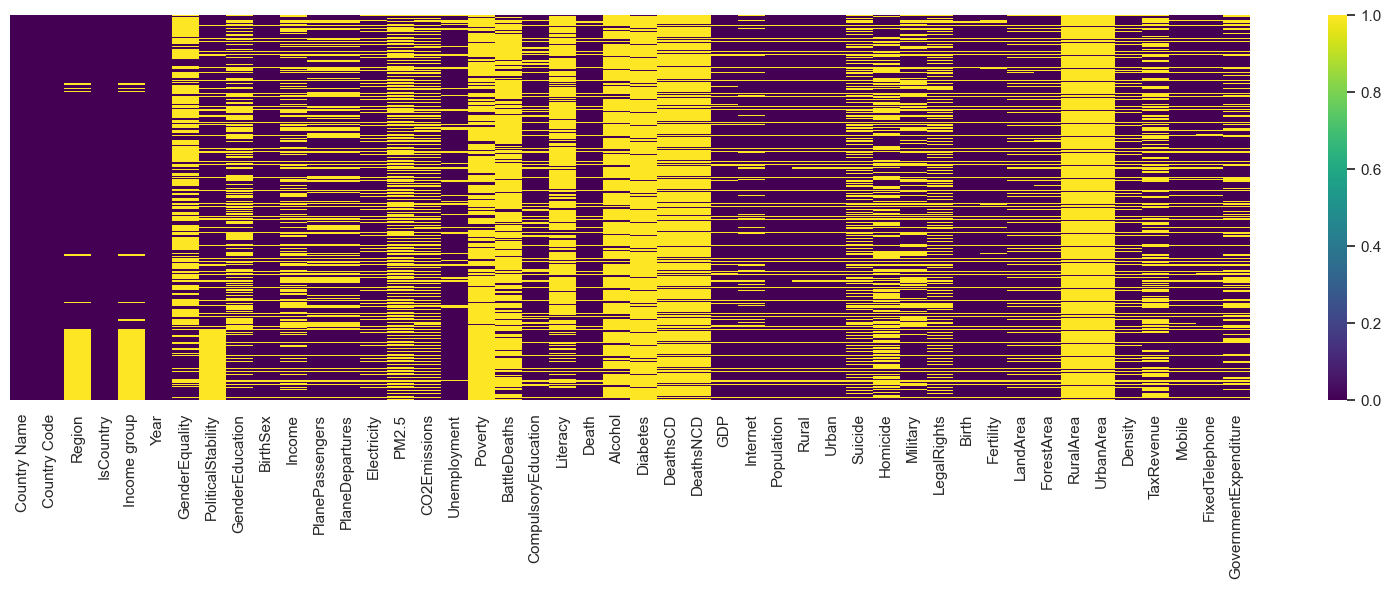

In [9]:
plt.figure(figsize=(20,5))
sns.heatmap(df.isnull(),yticklabels=False,cbar=True,cmap='viridis')
plt.show()

Here, yellow coloured boxes indicates null values of the respective column.

## 6. Handling Null Values

#### 1. Columns with a high percentage of missing values (above 70%)

In [10]:
[features for features in df.columns if df[features].isnull().sum()>2660*0.70]

['Poverty',
 'BattleDeaths',
 'Literacy',
 'Alcohol',
 'Diabetes',
 'DeathsCD',
 'DeathsNCD',
 'RuralArea',
 'UrbanArea']

For columns like Diabetes, RuralArea, UrbanArea, Poverty, BattleDeaths, DeathsNCD, DeathsCD, and Alcohol where more than 70% of the data is missing, dropping the entire column is often the most practical solution. The data is too sparse to be useful for most analyses, and imputing it would likely introduce significant bias or inaccurate information.

##### But I can not drop all these entire columns, why?
Our project goal includes exploring interesting relations using these variables. Hence, even though more than 80% data are missing in these columns, I can not drop the entire column.

##### Why not Imputation?
Filling in more than 80% of a column with the mean/median/mode values will distort the data's distribution. It could also lead to a false sense of a strong relationship with other variables, as the imputed values would all be identical or very close.

#### 2. Columns with a moderate percentage of missing values (10% to 70%)

In [11]:
[features for features in df.columns if 2660*0.10<df[features].isnull().sum()<2660*0.70]

['Region',
 'Income group',
 'GenderEquality',
 'PoliticalStability',
 'GenderEducation',
 'BirthSex',
 'Income',
 'PlanePassengers',
 'PlaneDepartures',
 'Electricity',
 'PM2.5',
 'CO2Emissions',
 'Unemployment',
 'CompulsoryEducation',
 'Death',
 'GDP',
 'Internet',
 'Population',
 'Rural',
 'Urban',
 'Suicide',
 'Homicide',
 'Military',
 'LegalRights',
 'Birth',
 'Fertility',
 'LandArea',
 'ForestArea',
 'Density',
 'TaxRevenue',
 'Mobile',
 'FixedTelephone',
 'GovernmentExpenditure']

The general strategy for handling moderate missing null values is to use imputation. 

##### Then why am I avoiding imputation?
My main goal in this project is to find relationships between variables, and imputing a high percentage of missing values can create a false sense of a relationship.

For example, if I will impute the missing 50% of PM2.5 values with the mean/median(if data is skewed then use median), I would be adding many identical or similar values to the dataset. Then when I will try to find a relationship between CO2Emissions and PM2.5, my analysis might show a correlation, but it could be an artificial one created by the imputed data rather than a true relationship that exists in the real data.

##### Then what is the solution?
Avoid imputatation and do pairwise analysis.

Instead of trying to use a single, complete dataset for a broad analysis, I will focus on analyzing relationships between two variables at a time, using only the data points where both variables have a value.
Using this strategy, I can get valuable insights without the risk of creating a false or misleading picture of the data

#### 3. Columns with a Low Percentage of Missing Values (under 10%)

In [12]:
[features for features in df.columns if df[features].isnull().sum()<2660*0.10]

['Country Name', 'Country Code', 'IsCountry', 'Year']

In [13]:
[features for features in df.columns if df[features].isnull().sum()==0]

['Country Name', 'Country Code', 'IsCountry', 'Year']

It includes 'Country Name', 'Country Code', 'IsCountry' and 'Year' columns of this dataset. 

However, there is no missing values in these columns as shown above. 
Hence, we do not need any imputation.

#### Is there any reason for choosing low threshold? Why 10% and not 25%?

Cosidering lower size of the dataset, it will be safer to use low threshold like 10% for imputation rather than 25%. Since the size of the dataset is not too big, imputing a quarter of the column might cause big impact on the result.

# Goal 1

 Explore the differences between income groups. For example, does the percentage of people using the Internet vary between income groups? Use graphical EDA or an ANOVA to study the differences, picking one year to focus on.

 (Fertility, alcohol consumption, forest area, and other variables may also be interesting to compare by income group.)

## 1.0 Choosing the year which has least null values for chosen variables

It is important to check which year has the most complete data for my chosen variables. This code will iterate through each year in the dataset and count the number of rows that have no missing values across all the variables of my interest.

#### Code for finding best year :

In [14]:
variables_of_interest = ['Income group', 'Internet', 'Fertility', 'Alcohol', 'ForestArea']
best_year = None
max_complete_rows = 0

for year in df['Year'].unique():
    df_subset = df[df['Year'] == year][variables_of_interest]
    num_complete_rows = df_subset.dropna().shape[0]
    if num_complete_rows > max_complete_rows:
        max_complete_rows = num_complete_rows
        best_year = year

print(f"The best year to use for a fixed-year comparison is: {best_year}")
print(f"This year provides {max_complete_rows} complete data points across all key variables.")

The best year to use for a fixed-year comparison is: 2015
This year provides 177 complete data points across all key variables.


#### Explanation of the code 

This code is a loop designed to find the **single best year** to use for a fixed-year analysis across a set of chosen variables. Here is a breakdown of how each part works.

##### **1. Defining Variables of Interest**

**variables_of_interest = ['Income group', 'Internet', 'Fertility', 'Alcohol', 'ForestArea']**

This line creates a Python list containing the names of all the columns you want to include in your analysis. The code will focus exclusively on these columns to determine data completeness.



##### **2. Initializing Tracker Variables**

**best_year = None**
**max_complete_rows = 0**

These two variables are set up to keep track of the best result found so far.
* **best_year** will store the year that has the most complete data.
* **max_complete_rows** will store the count of non-missing rows for that best year.
They are initialized to **None** and **0** because no years have been checked yet.

##### **3. Looping Through Each Year**

**for year in df['Year'].unique():**

This is the main part of the code. It iterates through every unique year present in the  **Year** column of the dataset. The  **.unique()** function ensures that the loop runs only once for each distinct year.

##### **4. Creating a Subset and Counting Complete Rows**

**df_subset = df[df['Year'] == year][variables_of_interest]**
**num_complete_rows = df_subset.dropna().shape[0]**

Inside the loop, for each year, the code performs two key actions:
* It creates a temporary **DataFrame** called **df_subset** that contains only the data from the current year and only for the **variables_of_interest**.
* It then uses the **.dropna()** method on this subset to remove any row where**at least one** of the chosen variables has a missing value. The **.shape[0]** then counts how many rows are left. This number, **num_complete_rows**, represents the total count of rows that are complete across all your key variables for that year.

##### **5. Finding the Maximum**

**if num_complete_rows > max_complete_rows:**
**max_complete_rows = num_complete_rows**
**best_year = year**

This **if** statement is the decision-making part of the code. It checks if the **num_complete_rows** for the current year is greater than the highest count found so far (**max_complete_rows**). If it is, the code updates the **max_complete_rows** and sets the **best_year** to the current year.

After the loop has checked every single year, the code prints the final  **best_year** and the total count of complete rows (**max_complete_rows**). This gives me the single best year to use for my analysis.

## 1.1 Does percentage of people using the Internet vary between income groups?

**Internet :**	Individuals using the Internet (% of population)

### Code :

In [95]:
df_2015 = df[df['Year'] == 2015]
df_2015

,Country Name,Country Code,Region,IsCountry,Income group,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
7,Afghanistan,AFG,South Asia,1,Low income,2015,1.500000,-2.571222,NaN,1.056000,...,5.405000,6.522300e+05,1.852782,6.361732e+05,3.993836e+03,51.750915,7.585382,1.970904e+07,1.100000e+05,NaN
17,Albania,ALB,Europe & Central Asia,1,Upper middle income,2015,NaN,0.346129,1.29878,1.091000,...,1.613000,2.740000e+04,28.802464,2.733160e+04,8.276940e+02,105.135146,18.515790,3.400955e+06,2.267180e+05,1.265151e+09
27,Algeria,DZA,Middle East & North Africa,1,Lower middle income,2015,NaN,-1.090160,1.36090,1.045000,...,3.041000,2.381741e+06,0.821248,2.305478e+06,9.357100e+03,16.602626,NaN,4.322764e+07,3.267592e+06,3.578571e+10
37,American Samoa,ASM,East Asia & Pacific,1,Upper middle income,2015,NaN,1.181357,NaN,1.060000,...,NaN,2.000000e+02,86.400000,1.982478e+02,2.343530e+01,256.840000,NaN,NaN,1.000000e+04,NaN
47,Andorra,AND,Europe & Central Asia,1,High income,2015,NaN,1.391288,NaN,1.061000,...,NaN,4.700000e+02,34.042553,4.094971e+02,3.093582e+01,152.651064,NaN,7.133600e+04,3.885000e+04,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617,Sub-Saharan Africa,SSF,NaN,0,NaN,2015,3.210526,NaN,0.73430,1.033840,...,4.956918,2.389092e+07,27.085549,2.385916e+07,1.150311e+05,42.221001,NaN,7.519997e+08,1.063345e+07,2.140482e+11
2627,Sub-Saharan Africa (excluding high income),SSA,NaN,0,NaN,2015,3.210526,NaN,0.73421,1.033840,...,4.957177,2.389046e+07,27.084659,2.385868e+07,1.150177e+05,42.217904,NaN,7.518515e+08,1.061211e+07,2.137269e+11
2637,Sub-Saharan Africa (IDA & IBRD countries),TSS,NaN,0,NaN,2015,3.210526,NaN,0.73430,1.033840,...,4.956918,2.389092e+07,27.085549,2.385916e+07,1.150311e+05,42.221001,NaN,7.519997e+08,1.063345e+07,2.140482e+11
2647,Upper middle income,UMC,NaN,0,NaN,2015,3.454545,NaN,1.15858,1.099445,...,1.849754,5.327666e+07,37.517330,5.217321e+07,7.858721e+05,45.384971,11.399752,2.577533e+09,4.086893e+08,3.226229e+12


In [96]:
df_goal1_a = df_2015[['Income group', 'Internet']].dropna()
df_goal1_a

,Income group,Internet
7,Low income,8.260000
17,Upper middle income,56.900000
27,Lower middle income,38.200000
47,High income,87.900000
57,Lower middle income,22.000000
...,...,...
2127,High income,54.839137
2137,Lower middle income,56.700000
2147,Low income,24.085409
2157,Low income,8.800000


In [97]:
internet_by_group = df_goal1_a.groupby('Income group')['Internet'].median().sort_values()
print("\nMedian Internet Usage by Income Group in 2015:")
print(internet_by_group)


Median Internet Usage by Income Group in 2015:
Income group
Low income              6.422211
Lower middle income    22.425704
Upper middle income    50.300000
High income            78.003019
Name: Internet, dtype: float64


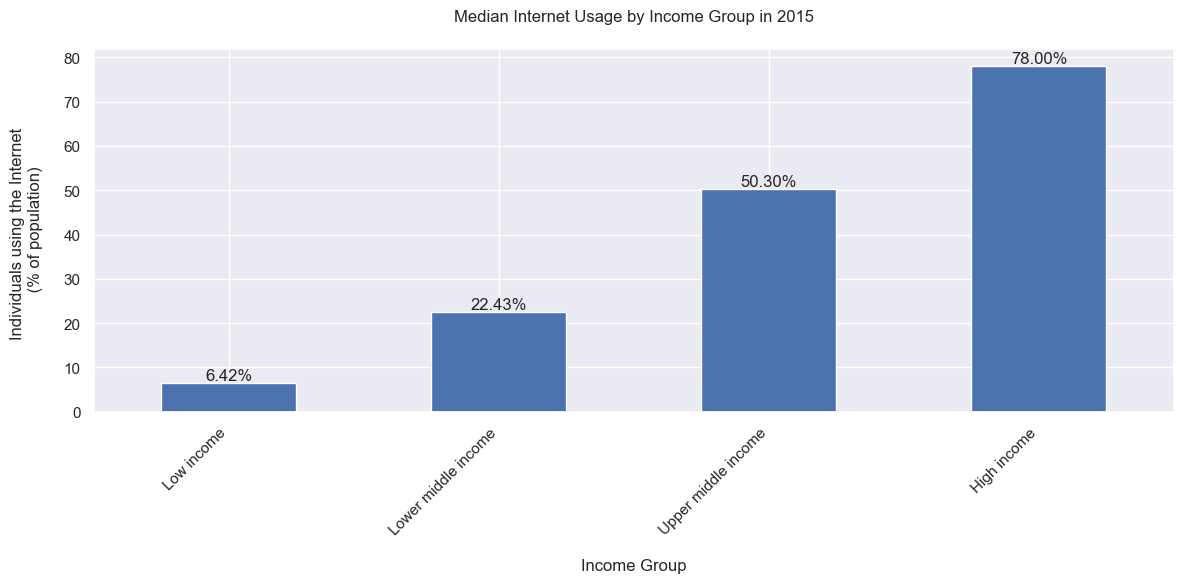

In [98]:
plt.figure(figsize=(12, 6))
ax = internet_by_group.plot(kind='bar')
for i, v in enumerate(internet_by_group):
    ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom')
plt.title('Median Internet Usage by Income Group in 2015', pad=20)
plt.xlabel('Income Group', labelpad=15)
plt.ylabel('Individuals using the Internet \n (% of population)', labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

##### Why not mean?

1. The mean has one main disadvantage: it is particularly susceptible to the influence of outliers. These are values that are unusual compared to the rest of the data set by being especially small or large in numerical value.
2. We usually prefer the median over the mean (or mode) when our data is skewed (i.e., the frequency distribution for our data is skewed).

### Explanation of code :

#### **1. Data Filtering**

 **df_2015 = df[df['Year'] == 2015]**: This is the **filtering** step. It creates a new DataFrame called **df_2015** that contains only the rows where the **Year** column is equal to 2015.

#### **2. Data Cleaning**

* **df_goal1_a = df_2015[['Income group', 'Internet']].dropna()**: This is a crucial line for handling missing data.
    * **[['Income group', 'Internet']]** selects only the two columns you're interested in for this specific analysis.
    * **.dropna()** removes any rows that have a missing value (**NaN**) in either the **Income group** or **Internet** column. This is a core part of the **pairwise analysis** strategy.

#### **3. Analysis and Aggregation**

* **internet_by_group = df_goal1_a.groupby('Income group')['Internet'].median().sort_values()**: This is the primary analysis line.
    * **.groupby('Income group')** splits the DataFrame into separate groups based on the unique values in the **Income group** column.
    * **['Internet']** selects the **Internet** column for the aggregation.
    * **.median()** calculates the median of the **Internet** values for each group.
    * **.sort_values()** sorts the results from the lowest average to the highest.

#### **4. Data Visualization**

* **plt.figure(figsize=(12, 6))**: This creates an empty figure and sets its size to 12 inches by 6 inches, giving you a good-sized plot.
* **ax = internet_by_group.plot(kind='bar')**: This command takes the results of your analysis and creates a bar chart. The **kind='bar'** argument specifies the type of plot. It stores the plot information in a variable **ax**, which is short for "axis," so you can easily modify it.
* **for i, v in enumerate(internet_by_group): ...**: This loop is what adds the percentage labels to the top of each bar. It iterates through the values of **internet_by_group** and uses the **ax.text()** function to place the text label at the correct **x** and **y** coordinates.
* **plt.title(...)**, **plt.xlabel(...)**, **plt.ylabel(...)**: These lines add a title to the plot and labels to the x and y axes, making the chart easy to understand.
* **plt.xticks(...)**: This command rotates the labels on the x-axis by 45 degrees, which prevents them from overlapping and makes them more readable.
* **plt.tight_layout()**: This automatically adjusts the plot's parameters to give a tight layout, preventing labels from being cut off.
* **plt.show()** and **plt.close()**: These commands display the plot and then close the figure, respectively. **plt.close()** is particularly useful for preventing multiple plots from being generated in an interactive environment.

### Observation:

There is a strong **positive correlation** between income group and the percentage of its population with Internet access. **High income groups have more percentage of population using the internet.**

## 1.2 Does fertility vary between income groups? 

### Code:

In [99]:
df_goal1_b = df_2015[['Income group', 'Fertility']].dropna()
df_goal1_b

,Income group,Fertility
7,Low income,5.405
17,Upper middle income,1.613
27,Lower middle income,3.041
57,Lower middle income,5.774
67,High income,1.567
...,...,...
2127,High income,2.110
2137,Lower middle income,4.046
2147,Low income,4.322
2157,Low income,4.793


In [100]:
fertility_by_group = df_goal1_b.groupby('Income group')['Fertility'].median().sort_values()
print("\nMedian Fertility by Income Group in 2015:")
print(fertility_by_group)


Median Fertility by Income Group in 2015:
Income group
High income            1.6820
Upper middle income    2.1315
Lower middle income    3.0870
Low income             4.9175
Name: Fertility, dtype: float64


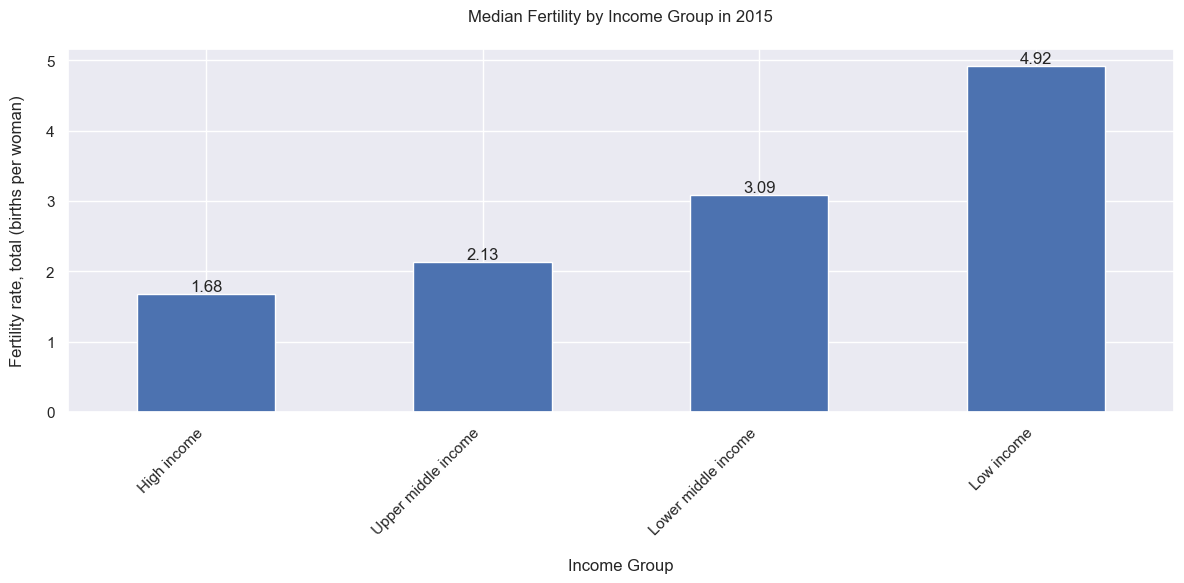

In [101]:
plt.figure(figsize=(12, 6))
bx = fertility_by_group.plot(kind='bar')
for i, v in enumerate(fertility_by_group):
    bx.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.title('Median Fertility by Income Group in 2015', pad=20)
plt.xlabel('Income Group', labelpad=15)
plt.ylabel('Fertility rate, total (births per woman)', labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

### Code Explanation

Similar as previous code with minor change in variables of interest, instead of income group and internet, we are now interested in exploring the relation between income group and fertility.

### Observation

Lower income groups groups have high median fertility rate. 

Fertility rate, total (births per woman) decreases as we move towards higher income groups. 

## 1.3 Does alcohol consumption vary between income groups? 

### Code :

In [103]:
df_goal1_c = df_2015[['Income group', 'Alcohol']].dropna()
df_goal1_c

,Income group,Alcohol
7,Low income,0.210
17,Upper middle income,6.740
27,Lower middle income,0.930
47,High income,11.010
57,Lower middle income,7.960
...,...,...
2097,Lower middle income,2.140
2117,Lower middle income,7.860
2147,Low income,0.055
2157,Low income,6.890


In [104]:
Alcohol_by_group = df_goal1_c.groupby('Income group')['Alcohol'].median().sort_values()
print("\nMedian Alcohol by Income Group in 2015:")
print(Alcohol_by_group)


Median Alcohol by Income Group in 2015:
Income group
Low income             2.19
Lower middle income    2.97
Upper middle income    6.63
High income            9.82
Name: Alcohol, dtype: float64


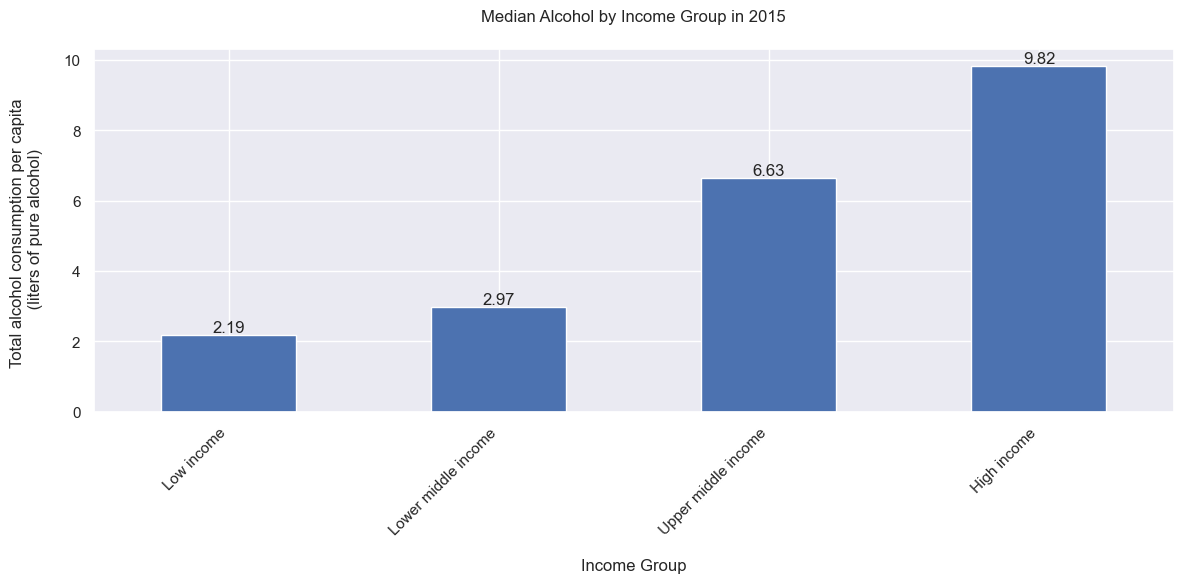

In [105]:
plt.figure(figsize=(12, 6))
bx = Alcohol_by_group.plot(kind='bar')
for i, v in enumerate(Alcohol_by_group):
    bx.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.title('Median Alcohol by Income Group in 2015', pad=20)
plt.xlabel('Income Group', labelpad=15)
plt.ylabel('Total alcohol consumption per capita \n (liters of pure alcohol)', labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

### Code Explanation

Similar as previous code with minor change in variables of interest, instead of income group and fertility, we are now interested in exploring the relation between income group and alcohol consumption.

### Observation

As peoples move to higher income groups their alcohol consumption incraeses.

## 1.4 Does forest area vary between income groups? 

### Code :

In [106]:
df_goal1_d = df_2015[['Income group', 'ForestArea']].dropna()
df_goal1_d

,Income group,ForestArea
7,Low income,1.852782
17,Upper middle income,28.802464
27,Lower middle income,0.821248
37,Upper middle income,86.400000
47,High income,34.042553
...,...,...
2127,High income,54.742857
2137,Lower middle income,1.684385
2147,Low income,1.039832
2157,Low income,61.549254


In [109]:
order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income_group_category = pd.CategoricalDtype(categories=order, ordered=True)
df_goal1_d['Income group'] = df_goal1_d['Income group'].astype(income_group_category)
ForestArea_by_group = df_goal1_d.groupby('Income group', observed=False)['ForestArea'].median()
print("\nMedian ForestArea by Income Group in 2015:")
print(ForestArea_by_group)


Median ForestArea by Income Group in 2015:
Income group
Low income             18.462913
Lower middle income    28.920513
Upper middle income    40.022470
High income            30.508742
Name: ForestArea, dtype: float64


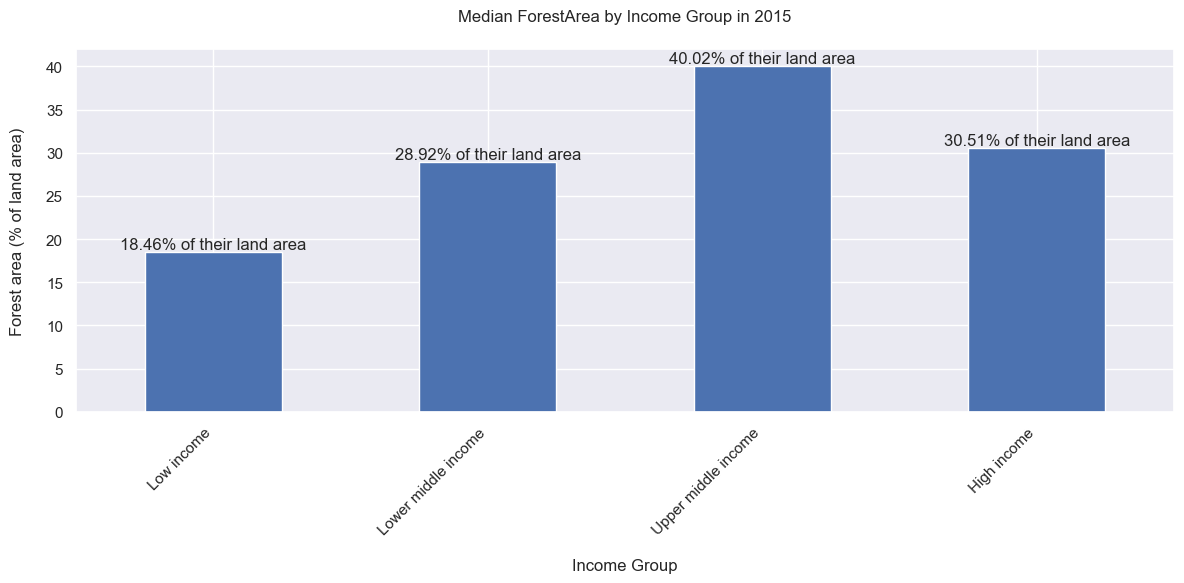

In [110]:
plt.figure(figsize=(12, 6))
bx = ForestArea_by_group.plot(kind='bar')
for i, v in enumerate(ForestArea_by_group):
    bx.text(i, v, f'{v:.2f}% of their land area', ha='center', va='bottom')
plt.title('Median ForestArea by Income Group in 2015', pad=20)
plt.xlabel('Income Group', labelpad=15)
plt.ylabel('Forest area (% of land area)', labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

### Do not get confused!

1. Adding all this percentages will exceed maximum 100% area but the plot above shown is not how much % of land area a income group owns, it is how much percentage of their land area is forest.
2. For land area, our dataset has column "LandArea" other than "ForestArea"

### Code Explanation

Similar as previous code with minor change in variables of interest, instead of income group and alcohol consumption, we are now interested in exploring the relation between income group and forest area.

### Observation

1. This is an interesting relation, peoples in low income group have least forest area which comes to be only a quarter of their land area.
2. Intrestingly, High income group have lower percentage compared to middle income group.
3. Upper middle income group has significantly high percentage of their land area as the forest area compared to other income groups.

## Conclusion :

1. There is a strong **positive correlation** between **income group** and the percentage of its population with **Internet access**. High income groups have __more percentage of population using the internet.__
2. Lower income groups groups have high median fertility rate. __Fertility rate decreases__ as we move towards higher income groups.
3. As peoples move to higher income groups their __alcohol consumption incraeses.__
4. 1. Peoples in __low income group have least forest area__ which comes to be only a quarter of their land area.
   2. Intrestingly, __High income group have lower percentage forest area__ compared to middle income group.
   3. __Upper middle income group has significantly high percentage__ of their land area as the forest area compared to other income groups.

# Goal 2

Explore the relationship between Internet access and political stability for all countries in 2016. Is there a positive or negative relationship? Fit a regression model and interpret the coefficients.

Now control for the country’s income group. Test whether an interaction term is necessary. Interpret the results. What does this interaction imply? Use a plot of the relationships to illustrate your results.

## 2.1 Relationship between Internet access and political stability for all countries in 2016.

In [111]:
df_2016 = df[(df["Year"]==2016) & (df["IsCountry"]==1)].copy()
df_2016

,Country Name,Country Code,Region,IsCountry,Income group,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
6,Afghanistan,AFG,South Asia,1,Low income,2016,1.5,-2.671054,NaN,1.055,...,5.262,652230.0,1.852782,NaN,NaN,53.104284,9.502653,21602982.0,114192.0,NaN
16,Albania,ALB,Europe & Central Asia,1,Upper middle income,2016,NaN,0.344645,1.321280,1.088,...,1.551,27400.0,28.802190,NaN,NaN,104.967190,17.590230,3369756.0,248640.0,1.324573e+09
26,Algeria,DZA,Middle East & North Africa,1,Lower middle income,2016,NaN,-1.097526,1.402080,1.044,...,3.051,2381741.0,0.821248,NaN,NaN,16.936908,NaN,47041321.0,3404709.0,3.625092e+10
36,American Samoa,ASM,East Asia & Pacific,1,Upper middle income,2016,NaN,1.193236,NaN,1.060,...,NaN,200.0,86.250000,NaN,NaN,252.240000,NaN,NaN,NaN,NaN
46,Andorra,AND,Europe & Central Asia,1,High income,2016,NaN,1.413419,NaN,1.061,...,NaN,470.0,34.042553,NaN,NaN,154.340426,NaN,76132.0,38694.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2126,Virgin Islands (U.S.),VIR,Latin America & Caribbean,1,High income,2016,NaN,0.999670,NaN,1.039,...,2.090,350.0,55.171429,NaN,NaN,307.188571,NaN,NaN,NaN,1.028545e+09
2136,West Bank and Gaza,PSE,Middle East & North Africa,1,Lower middle income,2016,NaN,-1.976399,1.371620,1.052,...,3.935,6020.0,1.684385,NaN,NaN,725.429900,5.313890,3713190.0,432000.0,3.584700e+09
2146,"Yemen, Rep.",YEM,Middle East & North Africa,1,Low income,2016,1.5,-2.794877,NaN,1.058,...,4.214,527970.0,1.039832,NaN,NaN,55.446336,NaN,16433055.0,1165828.0,NaN
2156,Zambia,ZMB,Sub-Saharan Africa,1,Low income,2016,3.0,0.142808,NaN,1.012,...,4.707,743390.0,61.295955,NaN,NaN,22.555807,13.353181,12017034.0,101407.0,NaN


In [112]:
df_reg = df_2016[['PoliticalStability', 'Internet', 'Income group']].copy()
df_reg

,PoliticalStability,Internet,Income group
6,-2.671054,11.000000,Low income
16,0.344645,59.600000,Upper middle income
26,-1.097526,42.945527,Lower middle income
36,1.193236,NaN,Upper middle income
46,1.413419,89.700000,High income
...,...,...,...
2126,0.999670,59.608316,High income
2136,-1.976399,59.900000,Lower middle income
2146,-2.794877,24.579208,Low income
2156,0.142808,10.300000,Low income


In [113]:
df_reg.isnull().sum()

PoliticalStability    11
Internet              14
Income group           1
dtype: int64

In [114]:
df_reg.dropna(inplace=True)
df_reg.isnull().sum()

PoliticalStability    0
Internet              0
Income group          0
dtype: int64

In [115]:
df_reg

,PoliticalStability,Internet,Income group
6,-2.671054,11.000000,Low income
16,0.344645,59.600000,Upper middle income
26,-1.097526,42.945527,Lower middle income
46,1.413419,89.700000,High income
56,-0.315899,23.200000,Lower middle income
...,...,...,...
2126,0.999670,59.608316,High income
2136,-1.976399,59.900000,Lower middle income
2146,-2.794877,24.579208,Low income
2156,0.142808,10.300000,Low income


## 2.2 Simple Linear Regression

In [116]:
y = df_reg['PoliticalStability']
X = df_reg['Internet']
X = sm.add_constant(X)
model1 = sm.OLS(y, X).fit()
print("Simple Linear Regression Model Summary (Political Stability vs. Internet)")
print(model1.summary())

Simple Linear Regression Model Summary (Political Stability vs. Internet)
                            OLS Regression Results                            
Dep. Variable:     PoliticalStability   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     107.6
Date:                Mon, 25 Aug 2025   Prob (F-statistic):           2.78e-20
Time:                        06:12:31   Log-Likelihood:                -228.19
No. Observations:                 193   AIC:                             460.4
Df Residuals:                     191   BIC:                             466.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

## 2.3 Linear Regression with Income Group and Interaction Term

The model is esssentially calculating $$ PoliticalStability = β_0 + β_1(Internet) + β_2(Low) + β_3(Lower Middle) + β_4(Upper Middle) $$

For a high-income country, the dummy variables for Low, Lower Middle, and Upper Middle are all 0. 
The equation simplifies to: Political Stability = $β_0 + β_1(Internet)$

Creating dummy variables for 'Income group'

In [117]:
df_reg

,PoliticalStability,Internet,Income group
6,-2.671054,11.000000,Low income
16,0.344645,59.600000,Upper middle income
26,-1.097526,42.945527,Lower middle income
46,1.413419,89.700000,High income
56,-0.315899,23.200000,Lower middle income
...,...,...,...
2126,0.999670,59.608316,High income
2136,-1.976399,59.900000,Lower middle income
2146,-2.794877,24.579208,Low income
2156,0.142808,10.300000,Low income


In [118]:
df_reg_dummies = pd.get_dummies(df_reg, columns=['Income group'], drop_first=True)
df_reg_dummies

,PoliticalStability,Internet,Income group_Low income,Income group_Lower middle income,Income group_Upper middle income
6,-2.671054,11.000000,True,False,False
16,0.344645,59.600000,False,False,True
26,-1.097526,42.945527,False,True,False
46,1.413419,89.700000,False,False,False
56,-0.315899,23.200000,False,True,False
...,...,...,...,...,...
2126,0.999670,59.608316,False,False,False
2136,-1.976399,59.900000,False,True,False
2146,-2.794877,24.579208,True,False,False
2156,0.142808,10.300000,True,False,False


When a regression model uses one-hot encoding on a categorical variable, one of the categories is dropped to serve as the **reference category**. This is done to prevent **multicollinearity**, a situation where independent variables in a regression are highly correlated with one another.

In my specific model, the **High income** category was used as the reference group because the one-hot encoding function was run with the **drop_first=True** option. This means the coefficients for **Income group_Low income**, **Income group_Lower middle income**, and **Income group_Upper middle income** represent the difference in the dependent variable (political stability) compared to the **High income** group. For example, the coefficient for **Income group_Low income** shows how much lower or higher a low-income country's political stability is, all else being equal, compared to a high-income country.

Therefore, the **Upper middle income** category isn't missing; its effect is implicitly captured in the coefficients of the other categories, all of which are measured relative to the reference group of **High income** countries.


**Define the dependent and independent variables**

In [119]:
y2 = df_reg_dummies['PoliticalStability']
X2 = df_reg_dummies.drop(columns=['PoliticalStability'])
X2

,Internet,Income group_Low income,Income group_Lower middle income,Income group_Upper middle income
6,11.000000,True,False,False
16,59.600000,False,False,True
26,42.945527,False,True,False
46,89.700000,False,False,False
56,23.200000,False,True,False
...,...,...,...,...
2126,59.608316,False,False,False
2136,59.900000,False,True,False
2146,24.579208,True,False,False
2156,10.300000,True,False,False


In [120]:
dummy_cols = [col for col in X2.columns if 'Income group' in col]
dummy_cols

['Income group_Low income',
 'Income group_Lower middle income',
 'Income group_Upper middle income']

**Create interaction terms for the new dummy variables**

In [121]:
dummy_cols = [col for col in X2.columns if 'Income group' in col]
dummy_cols

['Income group_Low income',
 'Income group_Lower middle income',
 'Income group_Upper middle income']

In [123]:
for col in dummy_cols:
    X2[f'Internet:{col}'] = X2['Internet'] * X2[col]
X2

,Internet,Income group_Low income,Income group_Lower middle income,Income group_Upper middle income,Internet:Income group_Low income,Internet:Income group_Lower middle income,Internet:Income group_Upper middle income
6,11.000000,True,False,False,11.000000,0.000000,0.0
16,59.600000,False,False,True,0.000000,0.000000,59.6
26,42.945527,False,True,False,0.000000,42.945527,0.0
46,89.700000,False,False,False,0.000000,0.000000,0.0
56,23.200000,False,True,False,0.000000,23.200000,0.0
...,...,...,...,...,...,...,...
2126,59.608316,False,False,False,0.000000,0.000000,0.0
2136,59.900000,False,True,False,0.000000,59.900000,0.0
2146,24.579208,True,False,False,24.579208,0.000000,0.0
2156,10.300000,True,False,False,10.300000,0.000000,0.0


**What are interaction terms here, and what is their use?**

These terms are designed to show how the relationship between Internet access and Political Stability differs across various income groups.

For example, the coefficient for Internet:Income group_Low income tells you the additional effect of a one-unit increase in Internet access for a low-income country, relative to the reference group (High-income countries).

In [124]:
for col in dummy_cols:
    X2[f'Internet:{col}'] = X2['Internet'] * X2[col]
X2

,Internet,Income group_Low income,Income group_Lower middle income,Income group_Upper middle income,Internet:Income group_Low income,Internet:Income group_Lower middle income,Internet:Income group_Upper middle income
6,11.000000,True,False,False,11.000000,0.000000,0.0
16,59.600000,False,False,True,0.000000,0.000000,59.6
26,42.945527,False,True,False,0.000000,42.945527,0.0
46,89.700000,False,False,False,0.000000,0.000000,0.0
56,23.200000,False,True,False,0.000000,23.200000,0.0
...,...,...,...,...,...,...,...
2126,59.608316,False,False,False,0.000000,0.000000,0.0
2136,59.900000,False,True,False,0.000000,59.900000,0.0
2146,24.579208,True,False,False,24.579208,0.000000,0.0
2156,10.300000,True,False,False,10.300000,0.000000,0.0


In [125]:
X2.dtypes

Internet                                     float64
Income group_Low income                         bool
Income group_Lower middle income                bool
Income group_Upper middle income                bool
Internet:Income group_Low income             float64
Internet:Income group_Lower middle income    float64
Internet:Income group_Upper middle income    float64
dtype: object

In [126]:
X2_numeric = X2.select_dtypes(include=np.number)
X2_numeric

,Internet,Internet:Income group_Low income,Internet:Income group_Lower middle income,Internet:Income group_Upper middle income
6,11.000000,11.000000,0.000000,0.0
16,59.600000,0.000000,0.000000,59.6
26,42.945527,0.000000,42.945527,0.0
46,89.700000,0.000000,0.000000,0.0
56,23.200000,0.000000,23.200000,0.0
...,...,...,...,...
2126,59.608316,0.000000,0.000000,0.0
2136,59.900000,0.000000,59.900000,0.0
2146,24.579208,24.579208,0.000000,0.0
2156,10.300000,10.300000,0.000000,0.0


In [127]:
X2_numeric = sm.add_constant(X2_numeric)
X2_numeric

,const,Internet,Internet:Income group_Low income,Internet:Income group_Lower middle income,Internet:Income group_Upper middle income
6,1.0,11.000000,11.000000,0.000000,0.0
16,1.0,59.600000,0.000000,0.000000,59.6
26,1.0,42.945527,0.000000,42.945527,0.0
46,1.0,89.700000,0.000000,0.000000,0.0
56,1.0,23.200000,0.000000,23.200000,0.0
...,...,...,...,...,...
2126,1.0,59.608316,0.000000,0.000000,0.0
2136,1.0,59.900000,0.000000,59.900000,0.0
2146,1.0,24.579208,24.579208,0.000000,0.0
2156,1.0,10.300000,10.300000,0.000000,0.0


In [128]:
model2 = sm.OLS(y2, X2_numeric).fit()

In [129]:
print("Linear Regression with Income Group and Interaction Term")
print(model2.summary())

Linear Regression with Income Group and Interaction Term
                            OLS Regression Results                            
Dep. Variable:     PoliticalStability   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     39.58
Date:                Mon, 25 Aug 2025   Prob (F-statistic):           5.07e-24
Time:                        06:13:31   Log-Likelihood:                -212.36
No. Observations:                 193   AIC:                             434.7
Df Residuals:                     188   BIC:                             451.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

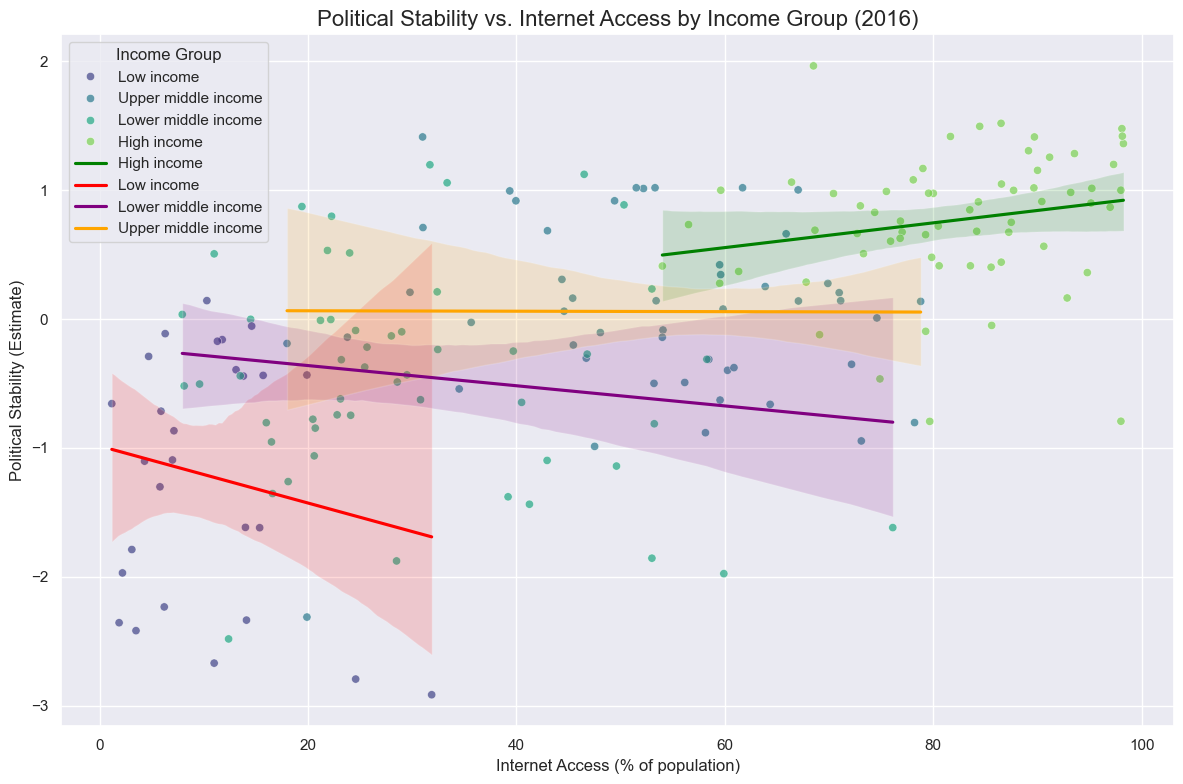

In [130]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Internet', y='PoliticalStability', hue='Income group', data=df_reg, palette='viridis', alpha=0.7)
sns.regplot(x='Internet', y='PoliticalStability', data=df_reg[df_reg['Income group'] == 'High income'], scatter=False, color='green', label='High income')
sns.regplot(x='Internet', y='PoliticalStability', data=df_reg[df_reg['Income group'] == 'Low income'], scatter=False, color='red', label='Low income')
sns.regplot(x='Internet', y='PoliticalStability', data=df_reg[df_reg['Income group'] == 'Lower middle income'], scatter=False, color='purple', label='Lower middle income')
sns.regplot(x='Internet', y='PoliticalStability', data=df_reg[df_reg['Income group'] == 'Upper middle income'], scatter=False, color='orange', label='Upper middle income')

plt.title('Political Stability vs. Internet Access by Income Group (2016)', fontsize=16)
plt.xlabel('Internet Access (% of population)', fontsize=12)
plt.ylabel('Political Stability (Estimate)', fontsize=12)
plt.legend(title='Income Group')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

### Observation :

1. The **coefficient for Internet** is approximately **0.0146.**
2. This is a positive value, indicating that as a country's Internet access percentage increases, its political stability index also tends to increase.
3. There is a **positive relationship.**

## 2.4 Ridge Regression

**Prepare the data for Ridge and LASSO**

In [131]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X2)
X_scaled

array([[-1.36957484,  2.47954596, -0.60728439, ...,  2.13088331,
        -0.52491475, -0.55479309],
       [ 0.31169347, -0.40329964, -0.60728439, ..., -0.32459298,
        -0.52491475,  1.89959739],
       [-0.26445134, -0.40329964,  1.64667497, ..., -0.32459298,
         2.26320965, -0.55479309],
       ...,
       [-0.89981573,  2.47954596, -0.60728439, ...,  5.16210368,
        -0.52491475, -0.55479309],
       [-1.39379064,  2.47954596, -0.60728439, ...,  1.97462572,
        -0.52491475, -0.55479309],
       [-0.95029596, -0.40329964,  1.64667497, ..., -0.32459298,
         0.9760892 , -0.55479309]])

In [132]:
y_scaled = y2
y_scaled

6      -2.671054
16      0.344645
26     -1.097526
46      1.413419
56     -0.315899
          ...   
2126    0.999670
2136   -1.976399
2146   -2.794877
2156    0.142808
2166   -0.619938
Name: PoliticalStability, Length: 193, dtype: float64

**Define different values for lambda (alpha in scikit-learn)**

In [133]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0]

In [134]:
print("Ridge Regression Results")
ridge_coeffs = {}
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y_scaled)
    ridge_coeffs[alpha] = ridge.coef_

for alpha, coeffs in ridge_coeffs.items():
    print(f"\nRidge (alpha={alpha}):")
    for name, coeff in zip(X2.columns, coeffs):
        print(f"  {name}: {coeff:.4f}")

Ridge Regression Results

Ridge (alpha=0.001):
  Internet: 0.2778
  Income group_Low income: -0.3342
  Income group_Lower middle income: -0.0810
  Income group_Upper middle income: 0.0390
  Internet:Income group_Low income: -0.1422
  Internet:Income group_Lower middle income: -0.2686
  Internet:Income group_Upper middle income: -0.2374

Ridge (alpha=0.01):
  Internet: 0.2775
  Income group_Low income: -0.3344
  Income group_Lower middle income: -0.0813
  Income group_Upper middle income: 0.0385
  Internet:Income group_Low income: -0.1422
  Internet:Income group_Lower middle income: -0.2685
  Internet:Income group_Upper middle income: -0.2371

Ridge (alpha=0.1):
  Internet: 0.2752
  Income group_Low income: -0.3364
  Income group_Lower middle income: -0.0844
  Income group_Upper middle income: 0.0345
  Internet:Income group_Low income: -0.1420
  Internet:Income group_Lower middle income: -0.2669
  Internet:Income group_Upper middle income: -0.2339

Ridge (alpha=0.5):
  Internet: 0.2678


## 2.5 LASSO Regression

In [135]:
print("LASSO Regression Results")

lasso_coeffs = {}
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_scaled, y_scaled)
    lasso_coeffs[alpha] = lasso.coef_

for alpha, coeffs in lasso_coeffs.items():
    print(f"\nLASSO (alpha={alpha}):")
    for name, coeff in zip(X2.columns, coeffs):
        print(f"  {name}: {coeff:.4f}")

LASSO Regression Results

LASSO (alpha=0.001):
  Internet: 0.2584
  Income group_Low income: -0.3522
  Income group_Lower middle income: -0.1043
  Income group_Upper middle income: 0.0000
  Internet:Income group_Low income: -0.1387
  Internet:Income group_Lower middle income: -0.2578
  Internet:Income group_Upper middle income: -0.2050

LASSO (alpha=0.01):
  Internet: 0.2927
  Income group_Low income: -0.3059
  Income group_Lower middle income: -0.0474
  Income group_Upper middle income: -0.0000
  Internet:Income group_Low income: -0.1389
  Internet:Income group_Lower middle income: -0.2712
  Internet:Income group_Upper middle income: -0.1748

LASSO (alpha=0.1):
  Internet: 0.3534
  Income group_Low income: -0.1302
  Income group_Lower middle income: -0.0000
  Income group_Upper middle income: -0.0000
  Internet:Income group_Low income: -0.0985
  Internet:Income group_Lower middle income: -0.1127
  Internet:Income group_Upper middle income: -0.0000

LASSO (alpha=0.5):
  Internet: 0.092

## 2.6 Comparing coefficients of different models

In [136]:
print("Comparison of Coefficients Across Models")
print("Feature\t\t\t\tOLS\t\tRidge (alpha=1.0)\tLASSO (alpha=0.1)")
ols_coeffs_dict = dict(zip(X2.columns, model2.params[1:].values))

for feature in ols_coeffs_dict:
    ridge_alpha_to_use = 1.0
    lasso_alpha_to_use = 0.1
    
    feature_index = list(X2.columns).index(feature)
    
    ridge_coeff = ridge_coeffs[ridge_alpha_to_use][feature_index]
    lasso_coeff = lasso_coeffs[lasso_alpha_to_use][feature_index]
    
    print(f"{feature:<25s}\t{ols_coeffs_dict[feature]:.4f}\t{ridge_coeff:.4f}\t\t{lasso_coeff:.4f}")

Comparison of Coefficients Across Models
Feature				OLS		Ridge (alpha=1.0)	LASSO (alpha=0.1)
Internet                 	0.0146	0.2624		0.3534
Income group_Low income  	-0.0726	-0.3453		-0.1302
Income group_Lower middle income	-0.0162	-0.1018		-0.0000
Income group_Upper middle income	-0.0059	0.0096		-0.0000


## Conclusion :

**OLS Regression**

The OLS coefficients represent the un-regularized baseline. It provides the most direct estimate of the linear relationship between each feature and the outcome, without any penalty for their size.

**Ridge Regression**

* It reduces the magnitude of all coefficients towards zero.
* It prevents any single feature from having too much influence but **never forces a coefficient to be exactly zero**.
* This means Ridge keeps all features in the model, making it useful for handling multicollinearity without discarding variables.

**LASSO Regression**

* It also shrinks coefficients, but its penalty can force them to become exactly zero. This effectively performs **automatic feature selection**, identifying and removing the less important variables from the model. 
* For example, the coefficients for the **Income group_Lower middle income** and **Income group_Upper middle income** categories, and their interaction terms, were all set to zero by LASSO.
* This suggests that these features are redundant or have a negligible effect once other variables are considered.

In conclusion, the comparison shows that Ridge is a great tool for stabilizing a model with many correlated predictors, while LASSO is better suited for creating a simpler, more interpretable model by focusing only on the most influential features.

# Goal 3

Many other relationships between variables could be explored in EDA, regression, or ANOVA. For instance:

1. Carbon dioxide emissions and PM 2.5 exposure, and how this relationship depends on GDP or income group
2. Gender parity in education (GenderEducation) and gender equality promotion by government policy (GenderEquality)
3. The strength of legal rights (LegalRights) and political stability (PoliticalStability)
4. Deaths in battle (BattleDeaths) and political stability (PoliticalStability)
5. Years of compulsory education (CompulsoryEducation) and literacy rate (Literacy)

## 3.1. Carbon dioxide emissions and PM 2.5 exposure, and how this relationship depends on GDP or income group

In [156]:
df31 = df[[ "CO2Emissions", "PM2.5", "Income group", "GDP"]]
df31

,CO2Emissions,PM2.5,Income group,GDP
0,NaN,NaN,Low income,NaN
1,NaN,NaN,Low income,1.478686e+10
2,NaN,NaN,Low income,2.014344e+10
3,0.160850,NaN,Low income,1.890449e+10
4,0.165367,NaN,Low income,1.841885e+10
...,...,...,...,...
2655,4.577625,45.673338,NaN,8.140950e+13
2656,4.557440,45.295799,NaN,7.646936e+13
2657,4.601850,47.364609,NaN,7.518636e+13
2658,4.677761,46.055167,NaN,7.973264e+13


In [157]:
df31.isnull().sum()

CO2Emissions     987
PM2.5           1450
Income group     550
GDP              360
dtype: int64

In [158]:
df3a = df31.dropna()
df3a

,CO2Emissions,PM2.5,Income group,GDP
5,0.134187,56.910808,Low income,1.889635e+10
6,0.153121,56.287047,Low income,1.801956e+10
7,0.176180,61.252656,Low income,1.999816e+10
8,0.149151,59.010330,Low income,2.055058e+10
9,0.189817,61.366745,Low income,2.056449e+10
...,...,...,...,...
2165,0.700660,22.251671,Lower middle income,1.758489e+10
2166,0.762286,21.726947,Lower middle income,2.054868e+10
2167,0.878337,21.733709,Lower middle income,1.996312e+10
2168,0.871688,22.805950,Lower middle income,1.949552e+10


In [159]:
df3a.isnull().sum()

CO2Emissions    0
PM2.5           0
Income group    0
GDP             0
dtype: int64

**Making a scatter plot for CO2Emission vs PM2.5**

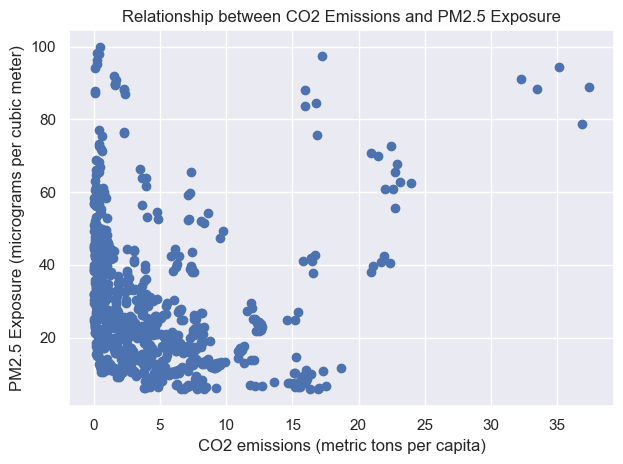

In [160]:
plt.scatter(df3a["CO2Emissions"], df3a["PM2.5"])
plt.title('Relationship between CO2 Emissions and PM2.5 Exposure')
plt.xlabel('CO2 emissions (metric tons per capita)')
plt.ylabel('PM2.5 Exposure (micrograms per cubic meter)')
plt.tight_layout()
plt.grid(True)
plt.show()

### Observation :

__Data points are clusttered together__ and there is **no linear pattern** for **CO2Emission** and **PM2.5.**

### Will there be any relationship between carbon dioxide emissions and PM2.5 exposure depending on the income level of a country?

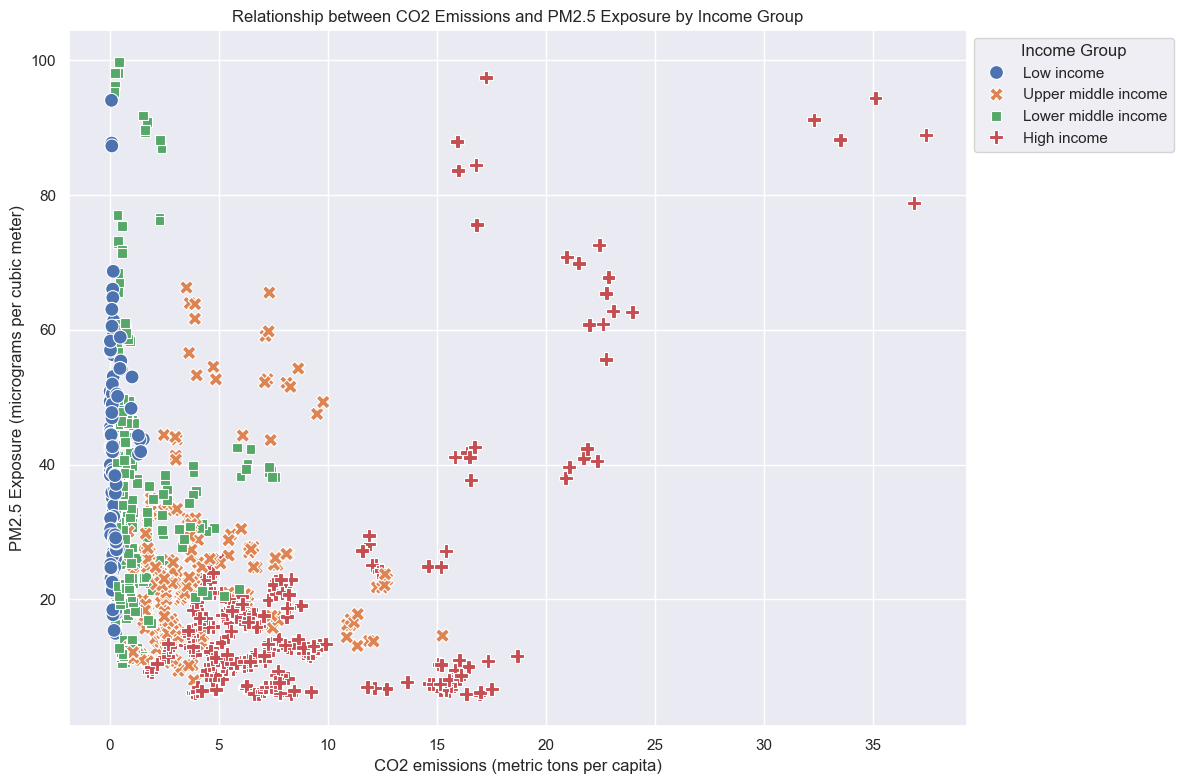

In [161]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df3a, x='CO2Emissions', y='PM2.5', hue='Income group', style='Income group', s=100)

plt.title('Relationship between CO2 Emissions and PM2.5 Exposure by Income Group')
plt.xlabel('CO2 emissions (metric tons per capita)')
plt.ylabel('PM2.5 Exposure (micrograms per cubic meter)')
plt.legend(title='Income Group', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.close()

### Observation :

Intestingly for **high income group contries** the **_PM2.5 exposure is low even with higher CO2Emission_**, while as we move to **lower income group contries** their ___PM2.5 exposure is comparatively high even with low CO2Emission.___

## 3.2. Gender parity in education (GenderEducation) and gender equality promotion by government policy (GenderEquality)

In [162]:
df32 = df[["GenderEquality", "GenderEducation"]]
df32

,GenderEquality,GenderEducation
0,NaN,NaN
1,NaN,NaN
2,1.500000,0.38689
3,1.500000,NaN
4,1.500000,0.34523
...,...,...
2655,3.216216,1.11526
2656,3.239726,1.11054
2657,3.309211,1.10362
2658,3.322368,1.10298


In [163]:
df32.isnull().sum()

GenderEquality     1619
GenderEducation    1206
dtype: int64

In [164]:
df3b = df32.dropna()
df3b

,GenderEquality,GenderEducation
2,1.500000,0.38689
4,1.500000,0.34523
8,1.500000,0.27600
59,3.000000,0.79661
89,4.500000,1.11728
...,...,...
2655,3.216216,1.11526
2656,3.239726,1.11054
2657,3.309211,1.10362
2658,3.322368,1.10298


In [165]:
df3b.isnull().sum()

GenderEquality     0
GenderEducation    0
dtype: int64

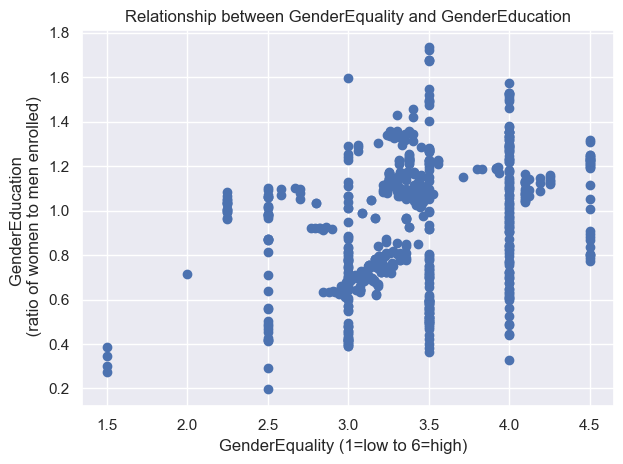

In [166]:
plt.scatter(df3b["GenderEquality"], df3b["GenderEducation"])
plt.title('Relationship between GenderEquality and GenderEducation')
plt.xlabel('GenderEquality (1=low to 6=high)  ')
plt.ylabel('GenderEducation \n (ratio of women to men enrolled)')
plt.tight_layout()
plt.grid(True)
plt.show()

### Observation :

1. The data points are more clustered at the higher end of the Gender Equality rating.
2. It suggests that while there isn't a perfect continuous relationship, __having strong government policies and institutions to promote gender equality is indeed associated with better gender parity in education.__

## 3.3. The strength of legal rights (LegalRights) and Political stability (PoliticalStability) 

**LegalRights :** Strength of legal rights index (0=weak to 12=strong)

**PoliticalStability :** Political stability and absence of violence/terrorism score (normalized as a z score)

In [167]:
df33 = df[["LegalRights", "PoliticalStability"]]
df33

,LegalRights,PoliticalStability
0,NaN,NaN
1,NaN,-2.529855
2,NaN,-2.705030
3,10.000000,-2.655531
4,10.000000,-2.763864
...,...,...
2655,5.347368,NaN
2656,5.036842,NaN
2657,4.942105,NaN
2658,4.804233,NaN


In [168]:
df33.isnull().sum()

LegalRights           1001
PoliticalStability     815
dtype: int64

In [169]:
df3c = df33.dropna()
df3c

,LegalRights,PoliticalStability
3,10.0,-2.655531
4,10.0,-2.763864
5,9.0,-2.801084
6,9.0,-2.671054
7,9.0,-2.571222
...,...,...
2165,5.0,-0.708769
2166,5.0,-0.619938
2167,5.0,-0.618156
2168,5.0,-0.713570


In [170]:
df3c.isnull().sum()

LegalRights           0
PoliticalStability    0
dtype: int64

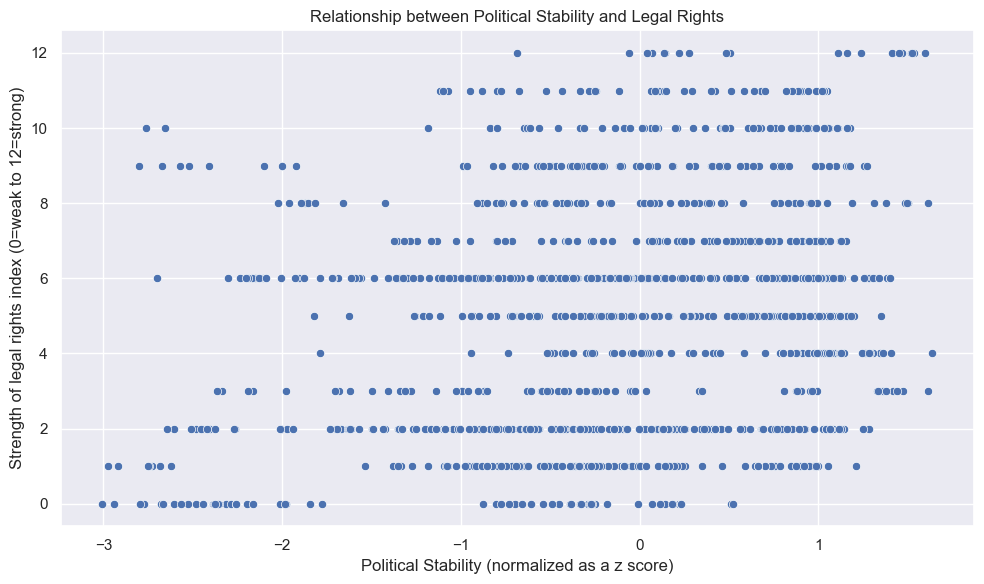

In [171]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PoliticalStability', y='LegalRights', data=df3c)
plt.title('Relationship between Political Stability and Legal Rights')
plt.xlabel('Political Stability (normalized as a z score)')
plt.ylabel('Strength of legal rights index (0=weak to 12=strong)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

### Observation :

1. The scatter plot shows a **positive relationship** between __PoliticalStability__ and __LegalRights__.
2. This means that as the country's __political stability increases, the strength of its legal rights also tends to increase.__

## 3.4. Deaths in battle (BattleDeaths) and political stability (PoliticalStability)

1. **PoliticalStability :** Political stability and absence of violence/terrorism score (normalized as a z score)
2. **BattleDeaths :** Battle-related deaths (number of people)

In [172]:
df34 = df[["PoliticalStability", "BattleDeaths"]]
df34

,PoliticalStability,BattleDeaths
0,NaN,NaN
1,-2.529855,35786.0
2,-2.705030,20475.0
3,-2.655531,29940.0
4,-2.763864,25676.0
...,...,...
2655,NaN,NaN
2656,NaN,NaN
2657,NaN,NaN
2658,NaN,NaN


In [173]:
df34.isnull().sum()

PoliticalStability     815
BattleDeaths          2232
dtype: int64

In [174]:
df3d = df34.dropna()
df3d.isnull().sum()
df3d

,PoliticalStability,BattleDeaths
1,-2.529855,35786.0
2,-2.705030,20475.0
3,-2.655531,29940.0
4,-2.763864,25676.0
5,-2.801084,19014.0
...,...,...
2145,-2.942443,3033.0
2146,-2.794877,2926.0
2147,-2.680222,6815.0
2148,-2.665575,1660.0


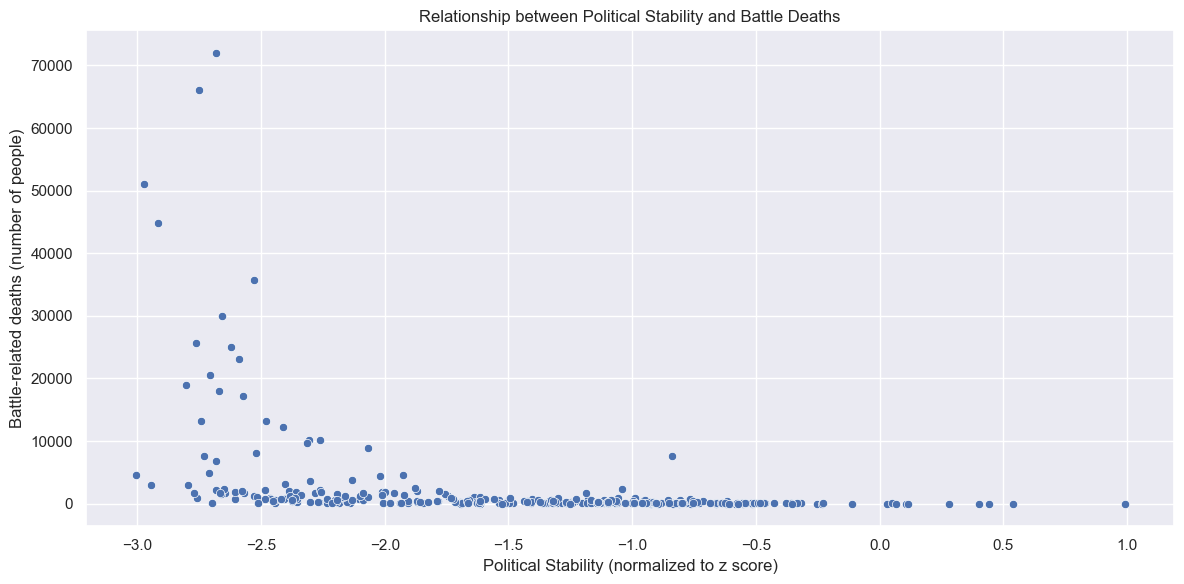

In [175]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='PoliticalStability', y='BattleDeaths', data=df3d)
plt.title('Relationship between Political Stability and Battle Deaths')
plt.xlabel('Political Stability (normalized to z score)')
plt.ylabel('Battle-related deaths (number of people)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

### Observation :

As the __political stability__ ___increases___ the __number of deaths__ ___decreases___.

## 3.5. Years of compulsory education (CompulsoryEducation) and literacy rate (Literacy)

1. **CompulsoryEducation :**	Compulsory education, duration (years)
2. **Literacy :**	Literacy rate, adult total (% of people ages 15 and above)

In [176]:
df35 = df[["CompulsoryEducation", "Literacy"]]
df35

,CompulsoryEducation,Literacy
0,NaN,NaN
1,9.0,37.266041
2,9.0,NaN
3,9.0,NaN
4,9.0,NaN
...,...,...
2655,10.0,86.248260
2656,10.0,86.008636
2657,10.0,85.559280
2658,9.0,85.401848


In [177]:
df35.isnull().sum()

CompulsoryEducation     473
Literacy               1922
dtype: int64

In [178]:
df3e = df35.dropna()
df3e.isnull().sum()
df3e

,CompulsoryEducation,Literacy
1,9.0,37.266041
11,9.0,98.449997
14,9.0,98.141151
24,10.0,81.407837
51,6.0,72.279999
...,...,...
2655,10.0,86.248260
2656,10.0,86.008636
2657,10.0,85.559280
2658,9.0,85.401848


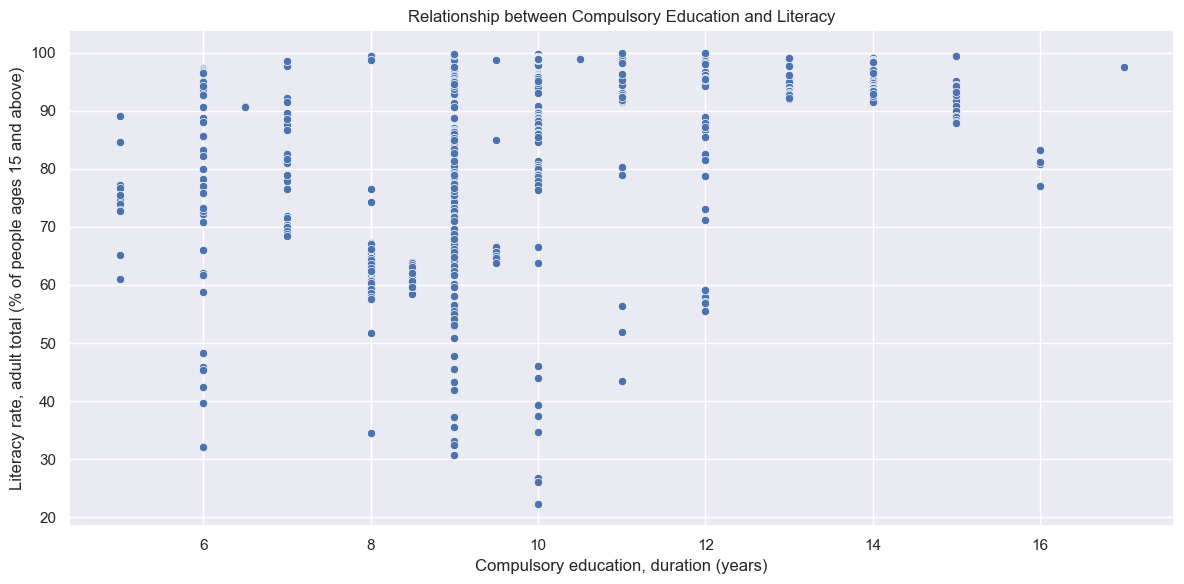

In [180]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='CompulsoryEducation', y='Literacy', data=df3e)
plt.title('Relationship between Compulsory Education and Literacy')
plt.xlabel('Compulsory education, duration (years)')
plt.ylabel('Literacy rate, adult total (% of people ages 15 and above)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

### Observation :

___More duration___ of __compulsory education__ are strongly associated with a ___higher___ __literacy rate__.

## Conclusion :

1. for **high income group contries** the **_PM2.5 exposure is low even with higher CO2Emission_**, while as we move to **lower income group contries** their ___PM2.5 exposure is comparatively high even with low CO2Emission.___
2. Having strong government policies and institutions to promote __gender equality__ is indeed associated with __better gender parity in education.__
3. As the country's __political stability increases, the strength of its legal rights also tends to increase.__
4. As the __political stability__ ___increases___ the __number of deaths__ ___decreases___
5. ___More duration___ of __compulsory education__ are strongly associated with a ___higher___ __literacy rate__.

# Goal 4

Other variables may change over time in interesting ways, such as airplane travel (PlaneDepartures and PlanePassengers), forest area (ForestArea), and diabetes prevalence (Diabetes).

## 4.1 Airplane travel (PlaneDepartures and PlanePassengers) over time.

1. **PlaneDepartures :**	Number of takeoffs of planes operated by air carriers registered in this country, domestically or from foreign airports
2. **PlanePassengers :**	Number of passengers carried by air carriers registered in this country 

In [181]:
df41 = df[["Year", "PlaneDepartures", "PlanePassengers"]]
df41

,Year,PlaneDepartures,PlanePassengers
0,2022,NaN,NaN
1,2021,2.865737e+03,2.932130e+05
2,2020,4.635714e+03,4.490410e+05
3,2019,7.334000e+03,1.066747e+06
4,2018,1.045400e+04,1.125367e+06
...,...,...,...
2655,2017,3.629946e+07,4.025616e+09
2656,2016,3.533771e+07,3.760774e+09
2657,2015,3.403059e+07,3.525115e+09
2658,2014,3.302672e+07,3.285081e+09


In [182]:
df41.isnull().sum()

Year                 0
PlaneDepartures    829
PlanePassengers    829
dtype: int64

In [183]:
df4_1 = df41.dropna()
df4_1.isnull().sum()

Year               0
PlaneDepartures    0
PlanePassengers    0
dtype: int64

In [184]:
df4_1

,Year,PlaneDepartures,PlanePassengers
1,2021,2.865737e+03,2.932130e+05
2,2020,4.635714e+03,4.490410e+05
3,2019,7.334000e+03,1.066747e+06
4,2018,1.045400e+04,1.125367e+06
5,2017,2.420700e+04,1.647425e+06
...,...,...,...
2655,2017,3.629946e+07,4.025616e+09
2656,2016,3.533771e+07,3.760774e+09
2657,2015,3.403059e+07,3.525115e+09
2658,2014,3.302672e+07,3.285081e+09


In [185]:
df4a = df4_1.groupby('Year')[["PlanePassengers", "PlaneDepartures"]].sum().reset_index()
df4a

,Year,PlanePassengers,PlaneDepartures
0,2013,2.560850e+10,2.621149e+08
1,2014,2.724666e+10,2.715035e+08
2,2015,2.942045e+10,2.816214e+08
3,2016,3.151328e+10,2.935629e+08
4,2017,3.395285e+10,3.032142e+08
5,2018,3.650349e+10,3.150972e+08
6,2019,3.791230e+10,3.210298e+08
7,2020,1.574244e+10,1.700151e+08
8,2021,1.967950e+10,2.014455e+08


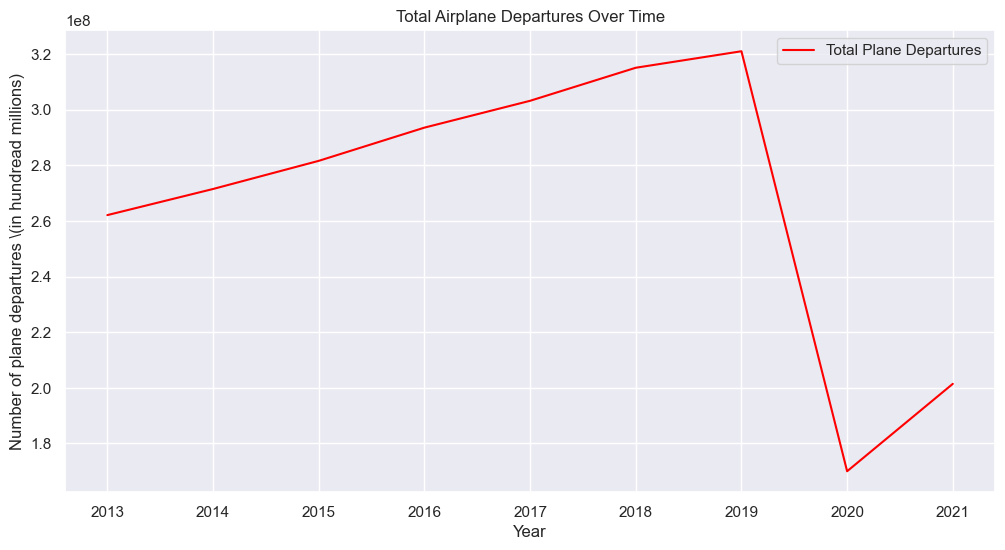

In [186]:
plt.figure(figsize=(12, 6))

plt.plot(df4a['Year'], df4a['PlaneDepartures'], label='Total Plane Departures', color='red')

plt.title('Total Airplane Departures Over Time')
plt.xlabel('Year')
plt.ylabel('Number of plane departures \(in hundread millions)')
plt.legend()
plt.grid(True)
plt.show()
plt.close()

Note : 1,000 million makes 1 billion.

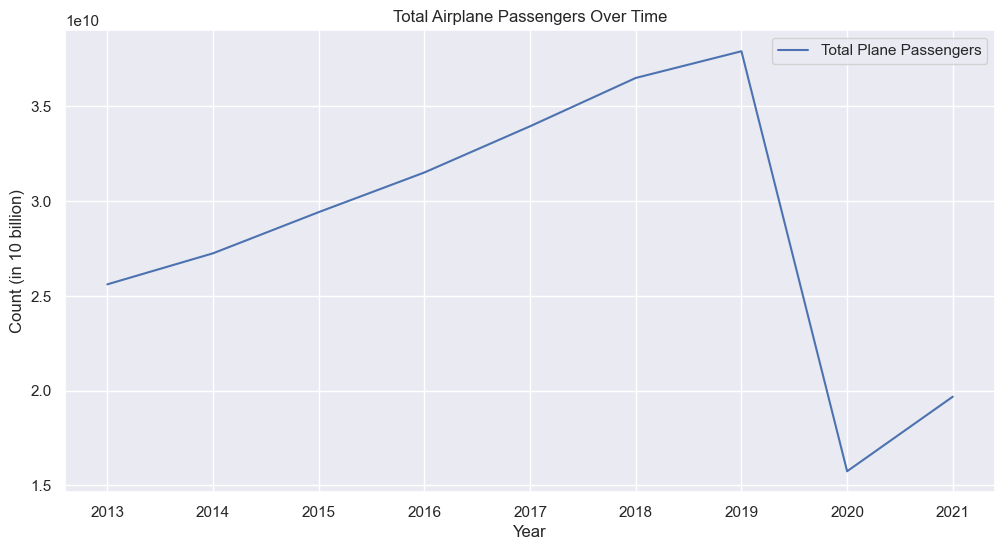

In [187]:
plt.figure(figsize=(12, 6))

plt.plot(df4a['Year'], df4a['PlanePassengers'], label='Total Plane Passengers')

plt.title('Total Airplane Passengers Over Time')
plt.xlabel('Year')
plt.ylabel('Count (in 10 billion)')
plt.grid(True)
plt.legend()
plt.show()
plt.close()

### Observation :

1. The plot shows a clear __upward trend in both plane passengers and departures, which abruptly drops in the year 2020.__
2. The sudden, dramatic drop in air travel is a clear reflection of the COVID-19 pandemic's effect on global mobility.

## 4.2 Forest area (ForestArea) over time (Year)

1. **ForestArea :** Forest area (% of land area)
2. **LandArea :** Land area (sq. km)

Here, my strategy is that I will make a copy of data with ForestArea and LandArea with Time. Since ForestArea is percentage, I can not group this data on year by year basis, So I will then make a seperate column "ForestAREA" which will be LandArea * ForestArea and thus I will get to know actual Forest area in sq. km. Now I can group this data by year by year basis and proceed furthur to understand how forest in sq. km. is affected by change of year, whether it increase or decreses.

In [188]:
df42 = df[["Year","LandArea", "ForestArea"]]
df42

,Year,LandArea,ForestArea
0,2022,NaN,NaN
1,2021,NaN,NaN
2,2020,6.522300e+05,1.852782
3,2019,6.522300e+05,1.852782
4,2018,6.522300e+05,1.852782
...,...,...,...
2655,2017,1.299797e+08,31.289988
2656,2016,1.299870e+08,31.340906
2657,2015,1.299772e+08,31.368377
2658,2014,1.299736e+08,31.403798


In [189]:
df42.isnull().sum()

Year            0
LandArea      556
ForestArea    564
dtype: int64

In [190]:
df4_2 = df42.dropna()
df4_2.isnull().sum()
df4_2

,Year,LandArea,ForestArea
2,2020,6.522300e+05,1.852782
3,2019,6.522300e+05,1.852782
4,2018,6.522300e+05,1.852782
5,2017,6.522300e+05,1.852782
6,2016,6.522300e+05,1.852782
...,...,...,...
2655,2017,1.299797e+08,31.289988
2656,2016,1.299870e+08,31.340906
2657,2015,1.299772e+08,31.368377
2658,2014,1.299736e+08,31.403798


In [191]:
df4_2['ForestAREA'] = (df4_2['LandArea'] * df4_2['ForestArea']) / 100
df4b = df4_2.groupby('Year')['ForestAREA'].sum().reset_index()
df4b

C:\Users\hello\AppData\Local\Temp\ipykernel_34924\405608357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4_2['ForestAREA'] = (df4_2['LandArea'] * df4_2['ForestArea']) / 100


,Year,ForestAREA
0,2013,4.287655e+08
1,2014,4.280547e+08
2,2015,4.273439e+08
3,2016,4.267693e+08
4,2017,4.258669e+08
5,2018,4.251710e+08
6,2019,4.244433e+08
7,2020,4.237343e+08


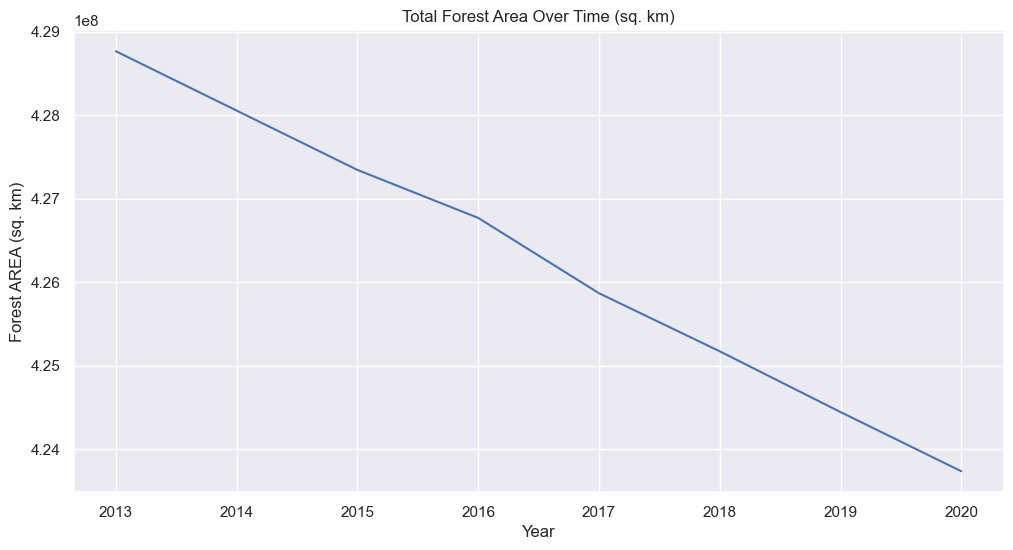

In [192]:
plt.figure(figsize=(12, 6))
plt.plot(df4b['Year'], df4b['ForestAREA'])

plt.title('Total Forest Area Over Time (sq. km)')
plt.xlabel('Year')
plt.ylabel('Forest AREA (sq. km)')
plt.grid(True)
plt.show()
plt.close()

### Observation :

The plot clearly shows that __as time moves forward, the total forest area is decreasing.__

## 4.3 Diabetes prevalence (Diabetes) over Time (Year)

**Diabetes :**	Diabetes prevalence (% of population ages 20 to 79)

In [193]:
df43 = df[["Year", "Diabetes"]]
df43

,Year,Diabetes
0,2022,NaN
1,2021,10.9
2,2020,NaN
3,2019,NaN
4,2018,NaN
...,...,...
2655,2017,NaN
2656,2016,NaN
2657,2015,NaN
2658,2014,NaN


In [194]:
df43.isnull().sum()

Year           0
Diabetes    2400
dtype: int64

In [195]:
df4c = df43.dropna()
df4c.isnull().sum()

Year        0
Diabetes    0
dtype: int64

In [196]:
df4c

,Year,Diabetes
1,2021,10.900000
11,2021,10.200000
21,2021,7.100000
31,2021,20.300000
41,2021,9.700000
...,...,...
2611,2021,5.794506
2621,2021,5.794205
2631,2021,5.794506
2641,2021,10.300785


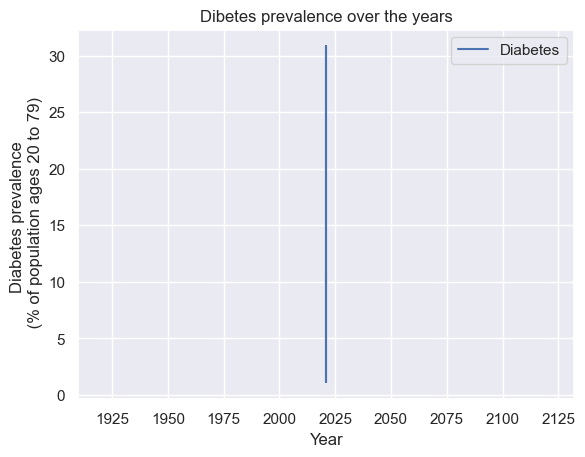

In [197]:
df4c.plot(x="Year", y="Diabetes")
plt.title("Dibetes prevalence over the years")
plt.xlabel("Year")
plt.ylabel("Diabetes prevalence \n (% of population ages 20 to 79)")
plt.legend()
plt.show()
plt.close()

### Observation :

1. All the __data__ for __Diabetes__ is from a __single year.__
2. The data doesn't contain the information needed to see how the diabetes prevalence changes over time.
3. Hence, this __limitations of the data__ restricts to form any conclusion.

## Conclusion :

1. We got __upward trend in both plane passengers and departures, which abruptly drops in the year 2020.__
2. As __time__ moves forward, the __total forest area__ is ___decreasing.___
3. 1. All the __data__ for __Diabetes__ is from a __single year.__
   2. The data doesn't contain the information needed to see how the diabetes prevalence changes over time.
   3. Hence, this __limitations of the data__ restricts to form any conclusion.

# Goal 5

What population can this data be said to be drawn from? Are tests necessary to generalize to that population?

## 5.1 What population can this data be said to be drawn from?

1. The World Bank compiles a __database of World Development Indicators__, which compile data from various sources intended to give the most current and accurate data about countries worldwide. Over a thousand different variables are available, updated yearly.
2. The World Development Indicators were __drawn from the DataBank service__ at https://databank.worldbank.org/source/world-development-indicators.
3. The dataset is a __census of the countries and economies tracked by the World Bank.__

## 5.2 Are tests necessary to generalize to that population?

1. The dataset was world development indicators of all the countries tracked by the World Bank, the __presence of many null values changed the nature of analysis performed on the data.__
2. When we __dropped rows with null values to analyze relation between specific variables__, the subset of the data we were left with was no longer a complete dataset. __It became a sample of the original population.__
3. __Since we were working with a sample, hypothesis tests are necessary to generalize__ our findings back to the full population of all countries tracked by the World Bank. This is because any conclusions we drawn from our analysis only applies to the subset of countries for which the data was complete, not to the entire group. Hypothesis testing allows us to determine if the relationships we observed in our sample are statistically significant and can be inferred to the larger population.

# FINAL REPORT

1. __Exploring differences between income groups using EDA__
    * There is a strong **positive correlation** between **income group** and the percentage of its population with **Internet access**. High income groups have __more percentage of population using the internet.__
    * Lower income groups groups have high median fertility rate. __Fertility rate decreases__ as we move towards higher income groups.
    * As peoples move to higher income groups their __alcohol consumption incraeses.__
    * * Peoples in __low income group have least forest area__ which comes to be only a quarter of their land area.
       * Intrestingly, __High income group have lower percentage forest area__ compared to middle income group.
       * __Upper middle income group has significantly high percentage__ of their land area as the forest area compared to other income groups.
2. __Regression Analysis : Ridge and Lasso Regression__
    * **OLS Regression**
        * The OLS coefficients represent the un-regularized baseline. It provides the most direct estimate of the linear relationship between each feature and the outcome, **without any penalty for their size.**
    * **Ridge Regression**
        * It reduces the magnitude of all coefficients towards zero.
        * It prevents any single feature from having too much influence but **never forces a coefficient to be exactly zero**.
        * This means Ridge keeps all features in the model, making it useful for handling multicollinearity without discarding variables.
    * **LASSO Regression**
        * It also shrinks coefficients, but __its penalty can force them to become exactly zero.__ This effectively performs **automatic feature selection**, identifying and removing the less important variables from the model.
        *  For example, the coefficients for the **Income group_Lower middle income** and **Income group_Upper middle income** categories, and their interaction terms, were all __set to zero by LASSO.__
        *  This suggests that these features are redundant or have a negligible effect once other variables are considered.
3. __Exploring intresting relations between other variables in EDA__
    * for **high income group contries** the **_PM2.5 exposure is low even with higher CO2Emission_**, while as we move to **lower income group contries** their ___PM2.5 exposure is comparatively high even with low CO2Emission.___
    * Having strong government policies and institutions to promote __gender equality__ is indeed associated with __better gender parity in education.__
    * As the country's __political stability increases, the strength of its legal rights also tends to increase.__
    * As the __political stability__ ___increases___ the __number of deaths__ ___decreases___
    * ___More duration___ of __compulsory education__ are strongly associated with a ___higher___ __literacy rate__.
4. __Analysing some more relations between variables__
    * We got __upward trend in both plane passengers and departures, which abruptly drops in the year 2020.__
    * As __time__ moves forward, the __total forest area__ is ___decreasing.___
    * * All the __data__ for __Diabetes__ is from a __single year.__
       * The data doesn't contain the information needed to see how the diabetes prevalence changes over time.
       * Hence, this __limitations of the data__ restricts to form any conclusion.
5. __Are tests necessary to generalize to the population?__
    * * The World Bank compiles a __database of World Development Indicators__, which compile data from various sources intended to give the most current and accurate data about countries worldwide. Over a thousand different variables are available, updated yearly.
       * The World Development Indicators were __drawn from the DataBank service__ at https://databank.worldbank.org/source/world-development-indicators.
       * The dataset is a __census of the countries and economies tracked by the World Bank.__
   *  * The dataset was world development indicators of all the countries tracked by the World Bank, the __presence of many null values changed the nature of analysis performed on the data.__
       * When we __dropped rows with null values to analyze relation between specific variables__, the subset of the data we were left with was no longer a complete dataset. __It became a sample of the original population.__
       * __Since we were working with a sample, hypothesis tests are necessary to generalize__ our findings back to the full population of all countries tracked by the World Bank. This is because any conclusions we drawn from our analysis only applies to the subset of countries for which the data was complete, not to the entire group. Hypothesis testing allows us to determine if the relationships we observed in our sample are statistically significant and can be inferred to the larger population.
